In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# 1. Load your pickled DataFrames
alz_df = pd.read_pickle("eeg_features_alzheimers.pkl")
cntrl_df = pd.read_pickle("eeg_features_controls.pkl")

In [3]:
try:
    result = alz_df[(alz_df['SubjectID'] == 'sub-001') & 
                     (alz_df['Electrode'] == 'Fp1') & 
                     (alz_df['WaveBand'] == 'Delta')]['Power'].iloc[0]
    print(f"Type: {type(result)}")
    print(f"Value: {result}")
except Exception as e:
    print(f"Method 1 error: {e}")


Type: <class 'numpy.float32'>
Value: 0.08257892727851868


In [4]:
# putting the labels for ML 0 and 1 
alz_df = alz_df.assign(Label=1)    # 1 for Alzheimer's
cntrl_df = cntrl_df.assign(Label=0)  # 0 for Controls


In [5]:
# note * getting slightly different value then Vaseline-AD-CN-2.2.ipynb

# Z-scoring

In [6]:
# Get unique combinations of electrodes and wavebands
electrodes = alz_df['Electrode'].unique()
wavebands = alz_df['WaveBand'].unique()

In [7]:

# Create copies to store the z-scored data
alz_df_z = alz_df.copy()
cntrl_df_z = cntrl_df.copy()

In [8]:
#testing subjects
# Get sorted list of subjects from each group
alz_subjects = sorted(alz_df['SubjectID'].unique())
cntrl_subjects = sorted(cntrl_df['SubjectID'].unique())

# Select the last 3 subjects from each group for testing
test_alz_subjects = alz_subjects[-3:]
test_cntrl_subjects = cntrl_subjects[-3:]

In [9]:
#training subjects
# Create train/test sets
alz_train_df = alz_df[~alz_df['SubjectID'].isin(test_alz_subjects)]
alz_test_df = alz_df[alz_df['SubjectID'].isin(test_alz_subjects)]


cntrl_train_df = cntrl_df[~cntrl_df['SubjectID'].isin(test_cntrl_subjects)]
cntrl_test_df = cntrl_df[cntrl_df['SubjectID'].isin(test_cntrl_subjects)]

In [10]:
# Combine train sets and test sets
train_df = pd.concat([alz_train_df, cntrl_train_df], ignore_index=True)
test_df = pd.concat([alz_test_df, cntrl_test_df], ignore_index=True)

In [11]:
print(f"\nTraining set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")



Training set size: 3076670
Test set size: 323665


In [12]:
def normalize_features(train_df, test_df):
    """
    Z-score normalize features by electrode-waveband combination
    using statistics from the training set only
    
    Args:
        train_df: DataFrame containing training data
        test_df: DataFrame containing test data
        
    Returns:
        train_df_z: Normalized training DataFrame
        test_df_z: Normalized test DataFrame (using train statistics)
    """
    # Create copies to store the z-scored data
    train_df_z = train_df.copy()
    test_df_z = test_df.copy()
    
    # Get unique combinations of electrodes and wavebands from training data
    electrodes = train_df['Electrode'].unique()
    wavebands = train_df['WaveBand'].unique()
    
    # Z-score Power values for each electrode-waveband combination
    for electrode in electrodes:
        for waveband in wavebands:
            # Get train data for this electrode-waveband combo
            train_mask = (train_df['Electrode'] == electrode) & (train_df['WaveBand'] == waveband)
            
            # Calculate mean and std from training data only
            train_powers = train_df.loc[train_mask, 'Power'].values
            mean_power = np.mean(train_powers)
            std_power = np.std(train_powers)
            
            # Apply z-score transformation to training data
            train_df_z.loc[train_mask, 'Power'] = (train_df.loc[train_mask, 'Power'] - mean_power) / std_power
            
            # Apply same transformation to test data
            test_mask = (test_df['Electrode'] == electrode) & (test_df['WaveBand'] == waveband)
            test_df_z.loc[test_mask, 'Power'] = (test_df.loc[test_mask, 'Power'] - mean_power) / std_power
    
    return train_df_z, test_df_z

In [13]:
# 4. Normalize features
train_df_z, test_df_z = normalize_features(train_df, test_df)


In [14]:
train_df_z.head()

,SubjectID,EpochID,WaveBand,Electrode,Power,Label
0,sub-020,ep-0,Delta,Fp1,-0.132571,1
1,sub-020,ep-0,Theta,Fp1,0.295758,1
2,sub-020,ep-0,Alpha,Fp1,0.321865,1
3,sub-020,ep-0,Beta,Fp1,-0.430876,1
4,sub-020,ep-0,Total,Fp1,1.000000,1


In [15]:
# DO a visualization here ! of C3 electrode or whatever 

In [16]:
train_pivot = train_df_z.pivot_table(
    index=['SubjectID', 'EpochID', 'Label'], 
    columns=['Electrode', 'WaveBand'], 
    values='Power'
)

test_pivot = test_df_z.pivot_table(
    index=['SubjectID', 'EpochID', 'Label'], 
    columns=['Electrode', 'WaveBand'], 
    values='Power'
)


In [17]:
print(f"\nTrain pivot shape: {train_pivot.shape}")
print(f"Test pivot shape: {test_pivot.shape}")
train_pivot.head()


Train pivot shape: (32386, 95)
Test pivot shape: (3407, 95)


Electrode                      C3                                      \
WaveBand                    Alpha      Beta     Delta     Theta Total   
SubjectID EpochID Label                                                 
sub-001   ep-0    1     -0.126200 -0.208551  0.233194 -0.225231   1.0   
          ep-1    1      0.049721 -0.009887  0.040126 -0.092381   1.0   
          ep-10   1     -0.235772  0.387732 -0.127070  0.110100   1.0   
          ep-100  1     -0.366377 -0.071085 -0.075169  0.372000   1.0   
          ep-101  1     -0.464805 -0.236419  0.428803 -0.384703   1.0   

Electrode                      C4                                      ...  \
WaveBand                    Alpha      Beta     Delta     Theta Total  ...   
SubjectID EpochID Label                                                ...   
sub-001   ep-0    1     -0.278236 -0.284342  0.410127 -0.416937   1.0  ...   
          ep-1    1     -0.269832  0.132820  0.003662  0.050438   1.0  ...   
          ep-10   1     -0.505110  0.223710  0.005687  0.112059   1.0  ...   
          ep-100  1     -0.474332 -0.226977 -0.188168  0.726204   1.0  ...   
          ep-101  1     -0.443984 -0.047517  0.387594 -0.438140   1.0  ...   

Electrode                      T5                                      \
WaveBand                    Alpha      Beta     Delta     Theta Total   
SubjectID EpochID Label                                                 
sub-001   ep-0    1     -0.512586 -0.300352  0.664526 -0.597261   1.0   
          ep-1    1     -0.427226 -0.150465  0.047685  0.574947   1.0   
          ep-10   1     -0.327881  1.034423 -0.000252 -0.152812   1.0   
          ep-100  1     -0.517957 -0.074714 -0.057463  0.891375   1.0   
          ep-101  1     -0.700229 -0.250525  0.734100 -0.521629   1.0   

Electrode                      T6                                      
WaveBand                    Alpha      Beta     Delta     Theta Total  
SubjectID EpochID Label                                                
sub-001   ep-0    1     -0.657609 -0.357412  0.859523 -0.811727   1.0  
          ep-1    1     -0.497361  0.029726 -0.003044  0.619927   1.0  
          ep-10   1     -0.529335  0.186297  0.227723  0.073076   1.0  
          ep-100  1     -0.690274 -0.100011  0.098335  0.720921   1.0  
          ep-101  1     -0.743762 -0.233553  0.567200 -0.144243   1.0  

[5 rows x 95 columns]

In [18]:
print(f"\nTrain pivot shape: {train_pivot.shape}")
print(f"Test pivot shape: {test_pivot.shape}")


Train pivot shape: (32386, 95)
Test pivot shape: (3407, 95)


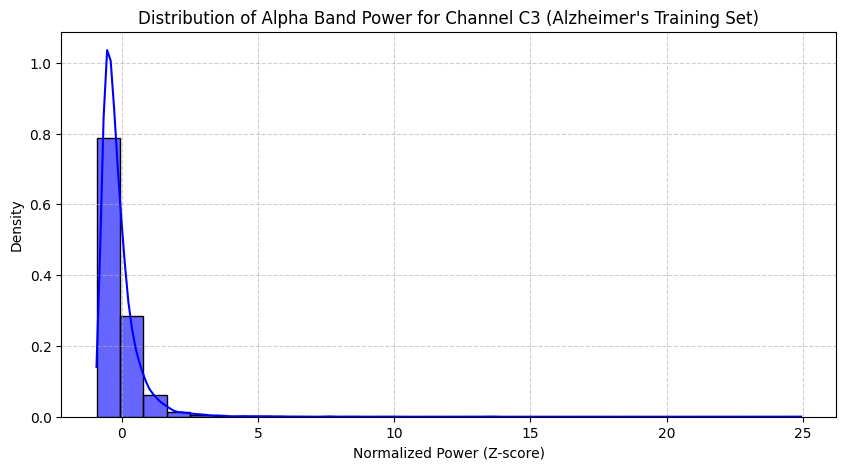

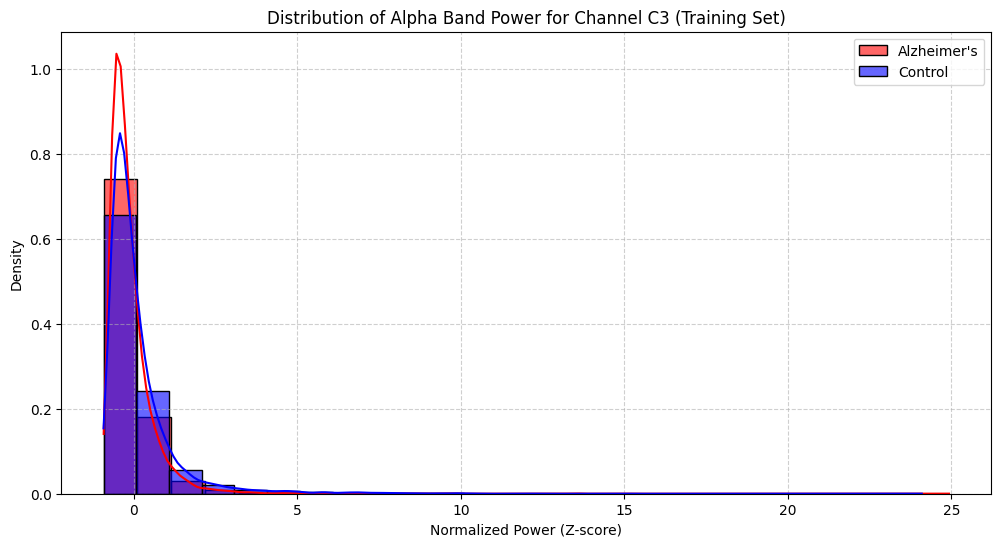

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
# After normalizing features (train_df_z and test_df_z are available)

# Extract only the "Alpha" band for channel "C3" for Alzheimer's patients from training data
alpha_c3_alz_mask = (train_df_z['Electrode'] == 'C3') & \
                    (train_df_z['WaveBand'] == 'Alpha') & \
                    (train_df_z['Label'] == 1)  # Assuming 1 is Alzheimer's

alpha_c3_data = train_df_z.loc[alpha_c3_alz_mask, 'Power'].values

# Plot histogram with density estimation
plt.figure(figsize=(10, 5))
sns.histplot(alpha_c3_data, bins=30, kde=True, color="blue", stat="density", alpha=0.6)

plt.ylabel("Density")
plt.xlabel("Normalized Power (Z-score)")
plt.title("Distribution of Alpha Band Power for Channel C3 (Alzheimer's Training Set)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Optional: Compare with Control group
alpha_c3_ctrl_mask = (train_df_z['Electrode'] == 'C3') & \
                     (train_df_z['WaveBand'] == 'Alpha') & \
                     (train_df_z['Label'] == 0)  # Assuming 0 is Control

alpha_c3_ctrl_data = train_df_z.loc[alpha_c3_ctrl_mask, 'Power'].values

# Plot comparative histogram
plt.figure(figsize=(12, 6))
sns.histplot(alpha_c3_data, bins=25, kde=True, color="red", stat="density", 
             alpha=0.6, label="Alzheimer's")
sns.histplot(alpha_c3_ctrl_data, bins=25, kde=True, color="blue", stat="density", 
             alpha=0.6, label="Control")

plt.ylabel("Density")
plt.xlabel("Normalized Power (Z-score)")
plt.title("Distribution of Alpha Band Power for Channel C3 (Training Set)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

 # PCA time 

In [25]:
pivot_df = train_df_z.pivot_table(
    index=['SubjectID', 'EpochID', 'Label'], 
    columns=['Electrode', 'WaveBand'], 
    values='Power'
)

In [26]:

# Extract feature matrix for PCA
X_pca = train_pivot.values

# Extract labels for coloring the scatter plot later
labels = pivot_df.index.get_level_values('Label').values

In [27]:
#Investigating mystery pivot_df

In [28]:
pivot_df.head()

Electrode                      C3                                      \
WaveBand                    Alpha      Beta     Delta     Theta Total   
SubjectID EpochID Label                                                 
sub-001   ep-0    1     -0.126200 -0.208551  0.233194 -0.225231   1.0   
          ep-1    1      0.049721 -0.009887  0.040126 -0.092381   1.0   
          ep-10   1     -0.235772  0.387732 -0.127070  0.110100   1.0   
          ep-100  1     -0.366377 -0.071085 -0.075169  0.372000   1.0   
          ep-101  1     -0.464805 -0.236419  0.428803 -0.384703   1.0   

Electrode                      C4                                      ...  \
WaveBand                    Alpha      Beta     Delta     Theta Total  ...   
SubjectID EpochID Label                                                ...   
sub-001   ep-0    1     -0.278236 -0.284342  0.410127 -0.416937   1.0  ...   
          ep-1    1     -0.269832  0.132820  0.003662  0.050438   1.0  ...   
          ep-10   1     -0.505110  0.223710  0.005687  0.112059   1.0  ...   
          ep-100  1     -0.474332 -0.226977 -0.188168  0.726204   1.0  ...   
          ep-101  1     -0.443984 -0.047517  0.387594 -0.438140   1.0  ...   

Electrode                      T5                                      \
WaveBand                    Alpha      Beta     Delta     Theta Total   
SubjectID EpochID Label                                                 
sub-001   ep-0    1     -0.512586 -0.300352  0.664526 -0.597261   1.0   
          ep-1    1     -0.427226 -0.150465  0.047685  0.574947   1.0   
          ep-10   1     -0.327881  1.034423 -0.000252 -0.152812   1.0   
          ep-100  1     -0.517957 -0.074714 -0.057463  0.891375   1.0   
          ep-101  1     -0.700229 -0.250525  0.734100 -0.521629   1.0   

Electrode                      T6                                      
WaveBand                    Alpha      Beta     Delta     Theta Total  
SubjectID EpochID Label                                                
sub-001   ep-0    1     -0.657609 -0.357412  0.859523 -0.811727   1.0  
          ep-1    1     -0.497361  0.029726 -0.003044  0.619927   1.0  
          ep-10   1     -0.529335  0.186297  0.227723  0.073076   1.0  
          ep-100  1     -0.690274 -0.100011  0.098335  0.720921   1.0  
          ep-101  1     -0.743762 -0.233553  0.567200 -0.144243   1.0  

[5 rows x 95 columns]

In [29]:
print(labels)

[1 1 1 ... 0 0 0]


In [30]:
schema = pd.DataFrame({ 
    'column': pivot_df.columns,
    'dtype': pivot_df.dtypes.values
})
print(schema.head(98))

         column    dtype
0   (C3, Alpha)  float32
1    (C3, Beta)  float32
2   (C3, Delta)  float32
3   (C3, Theta)  float32
4   (C3, Total)  float32
..          ...      ...
90  (T6, Alpha)  float32
91   (T6, Beta)  float32
92  (T6, Delta)  float32
93  (T6, Theta)  float32
94  (T6, Total)  float32

[95 rows x 2 columns]


In [31]:
# Print structure
print("PCA Input Shape:", X_pca.shape)  # (n_samples, n_features)
print("Feature Names:", pivot_df.columns.tolist())  # Check feature names
print("NaNs in X_train:", np.isnan(X_pca).sum())

PCA Input Shape: (32386, 95)
Feature Names: [('C3', 'Alpha'), ('C3', 'Beta'), ('C3', 'Delta'), ('C3', 'Theta'), ('C3', 'Total'), ('C4', 'Alpha'), ('C4', 'Beta'), ('C4', 'Delta'), ('C4', 'Theta'), ('C4', 'Total'), ('Cz', 'Alpha'), ('Cz', 'Beta'), ('Cz', 'Delta'), ('Cz', 'Theta'), ('Cz', 'Total'), ('F3', 'Alpha'), ('F3', 'Beta'), ('F3', 'Delta'), ('F3', 'Theta'), ('F3', 'Total'), ('F4', 'Alpha'), ('F4', 'Beta'), ('F4', 'Delta'), ('F4', 'Theta'), ('F4', 'Total'), ('F7', 'Alpha'), ('F7', 'Beta'), ('F7', 'Delta'), ('F7', 'Theta'), ('F7', 'Total'), ('F8', 'Alpha'), ('F8', 'Beta'), ('F8', 'Delta'), ('F8', 'Theta'), ('F8', 'Total'), ('Fp1', 'Alpha'), ('Fp1', 'Beta'), ('Fp1', 'Delta'), ('Fp1', 'Theta'), ('Fp1', 'Total'), ('Fp2', 'Alpha'), ('Fp2', 'Beta'), ('Fp2', 'Delta'), ('Fp2', 'Theta'), ('Fp2', 'Total'), ('Fz', 'Alpha'), ('Fz', 'Beta'), ('Fz', 'Delta'), ('Fz', 'Theta'), ('Fz', 'Total'), ('O1', 'Alpha'), ('O1', 'Beta'), ('O1', 'Delta'), ('O1', 'Theta'), ('O1', 'Total'), ('O2', 'Alpha'), ('O2

In [32]:
# Handle any NaN values if present
if np.isnan(X_pca).sum() > 0:
    print("Handling NaN values by filling with mean values")
    col_mean = np.nanmean(X_pca, axis=0)
    inds = np.where(np.isnan(X_pca))
    X_pca[inds] = np.take(col_mean, inds[1])


In [33]:
# Apply PCA (reduce to 15 components)
pca = PCA(n_components=20)
X_pca_transformed = pca.fit_transform(X_pca)


In [34]:
pca.explained_variance_ratio_

array([0.6081212 , 0.11262665, 0.0914104 , 0.03220903, 0.01880653,
       0.01428137, 0.01190393, 0.01007132, 0.00827536, 0.007653  ,
       0.00618728, 0.0059329 , 0.00517969, 0.00475384, 0.00426253,
       0.00416598, 0.00388   , 0.00371929, 0.00333309, 0.0031079 ],
      dtype=float32)

In [35]:
import numpy as np

# Your array
explained_variance = np.array([0.6081212, 0.1126665, 0.0914104, 0.0322903, 0.0188653,
                              0.0142137, 0.0119393, 0.0107132, 0.0082536, 0.00763,
                              0.0061728, 0.005329, 0.0051969, 0.0047584, 0.0042253,
                              0.0041598, 0.00388, 0.0037929, 0.0033309, 0.003079])

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Print components needed for different variance thresholds
print(f"Components needed for 80% variance: {np.argmax(cumulative_variance >= 0.80) + 1}")
print(f"Components needed for 90% variance: {np.argmax(cumulative_variance >= 0.90) + 1}")
print(f"Components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")

Components needed for 80% variance: 3
Components needed for 90% variance: 8
Components needed for 95% variance: 18


PCA Output Shape: (32386, 20)
Explained Variance Ratio: [0.6081212  0.11262665 0.0914104  0.03220903 0.01880653 0.01428137
 0.01190393 0.01007132 0.00827536 0.007653   0.00618728 0.0059329
 0.00517969 0.00475384 0.00426253 0.00416598 0.00388    0.00371929
 0.00333309 0.0031079 ]
Cumulative Explained Variance: [0.6081212  0.7207479  0.8121583  0.8443673  0.86317384 0.87745523
 0.8893592  0.8994305  0.90770584 0.91535884 0.9215461  0.927479
 0.93265873 0.93741256 0.94167507 0.9458411  0.9497211  0.95344037
 0.95677346 0.95988137]


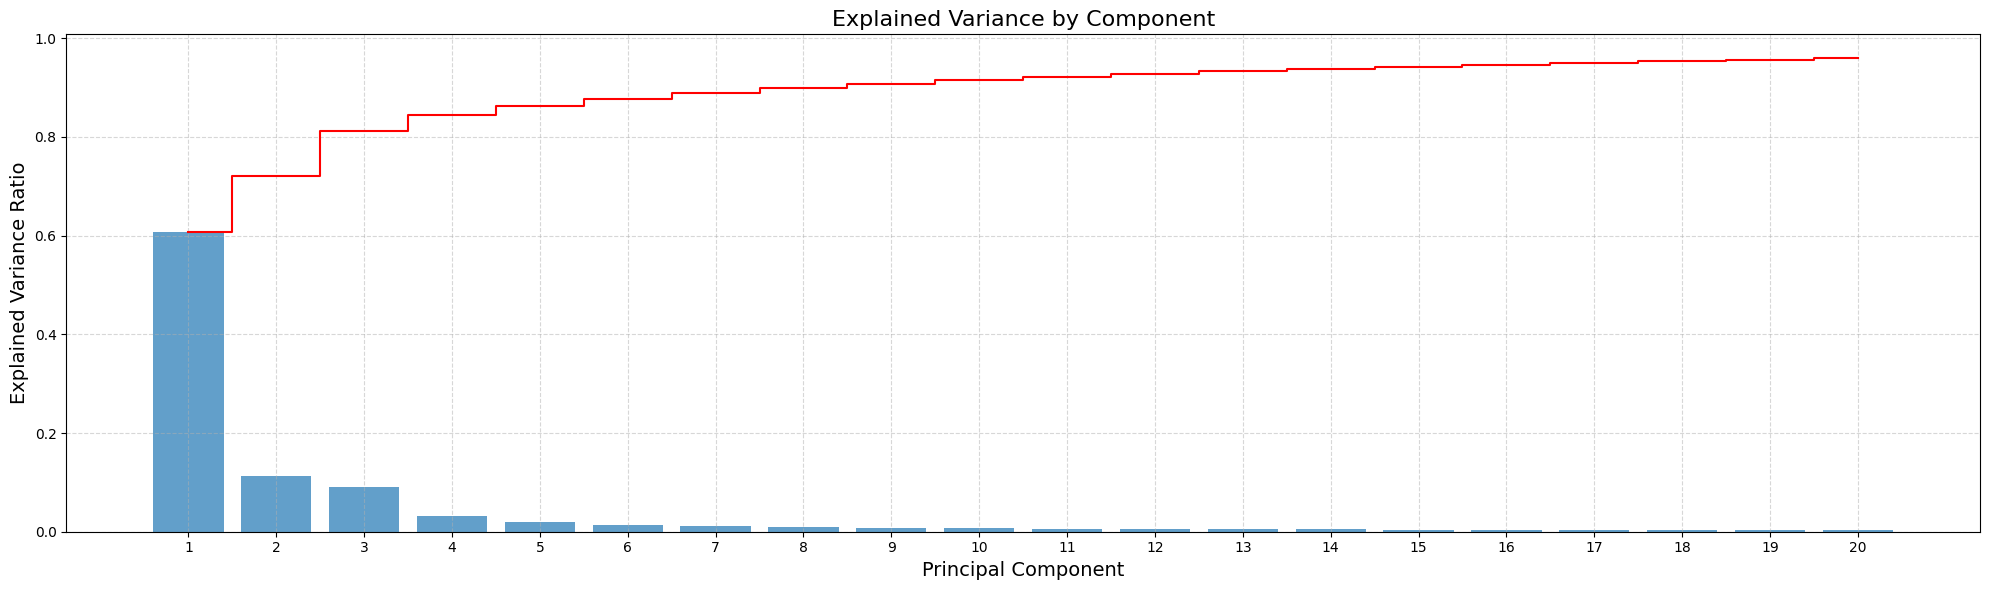

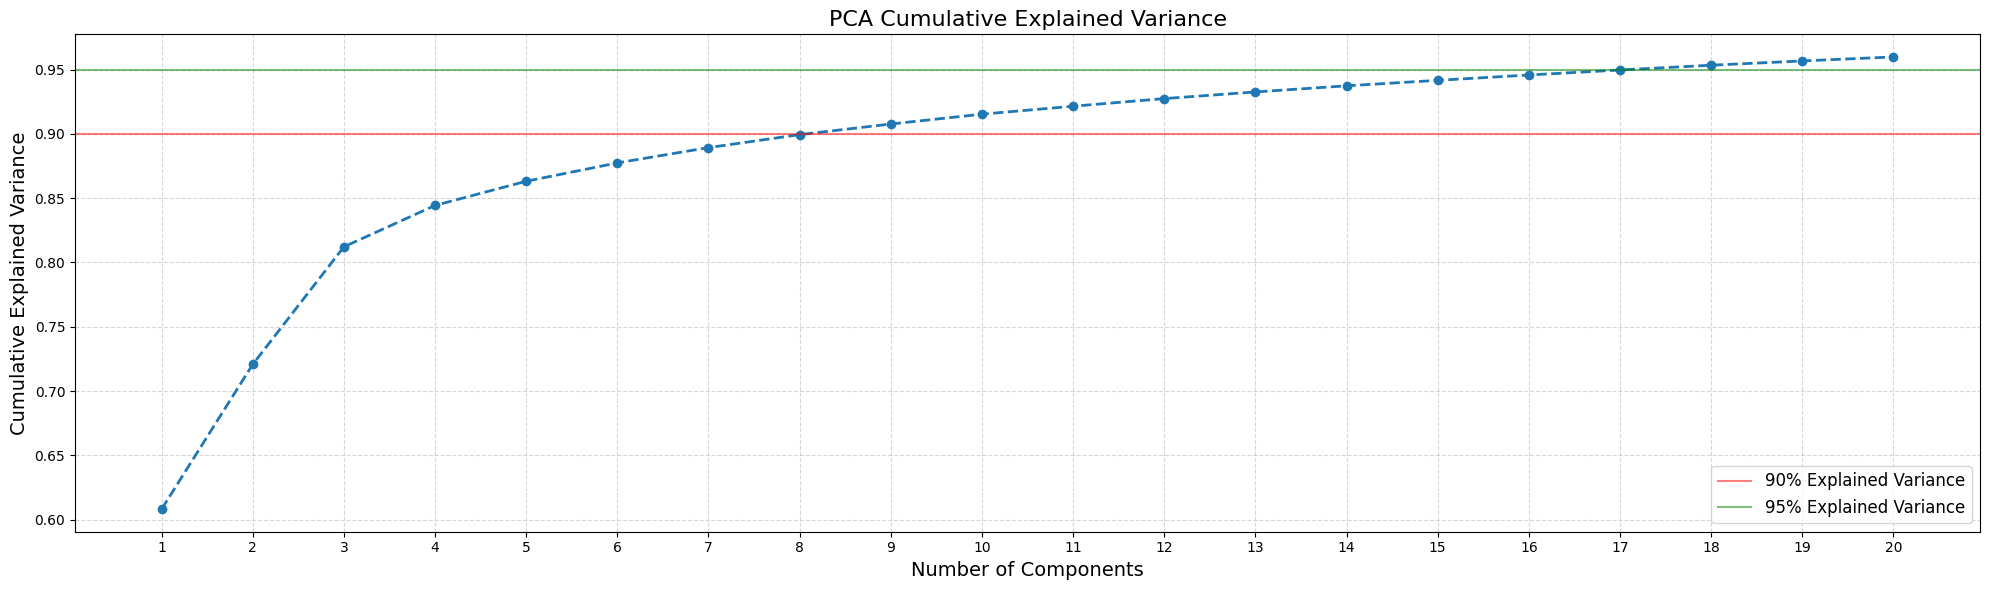

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Print PCA results
print("PCA Output Shape:", X_pca_transformed.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", np.cumsum(pca.explained_variance_ratio_))

# Plot the explained variance
plt.figure(figsize=(20, 6))
plt.bar(range(1, 21), pca.explained_variance_ratio_, alpha=0.7, align='center')
plt.step(range(1, 21), np.cumsum(pca.explained_variance_ratio_), where='mid', color='red')
plt.xlabel('Principal Component', fontsize=14)
plt.ylabel('Explained Variance Ratio', fontsize=14)
plt.title('Explained Variance by Component', fontsize=16)
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot the cumulative explained variance
plt.figure(figsize=(20, 6))
plt.plot(range(1, 21), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', linewidth=2)
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Cumulative Explained Variance', fontsize=14)
plt.title('PCA Cumulative Explained Variance', fontsize=16)
plt.axhline(y=0.9, color='r', linestyle='-', alpha=0.5, label='90% Explained Variance')
plt.axhline(y=0.95, color='g', linestyle='-', alpha=0.5, label='95% Explained Variance')
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Plot the first two principal components
plt.figure(figsize=(20, 10))
scatter = plt.scatter(
    X_pca_transformed[:, 0], 
    X_pca_transformed[:, 1], 
    c=labels,  # Color by class label
    cmap='viridis', 
    alpha=0.7,
    s=80,
    edgecolors='w'
)

plt.colorbar(scatter, label='Class (0=Control, 1=Alzheimer\'s)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=14)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=14)
plt.title('PCA: First Two Principal Components', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Create a scatter plot matrix of the first few principal components
from pandas.plotting import scatter_matrix

# Convert first 4 PCs to DataFrame for scatter matrix
pc_df = pd.DataFrame(
    X_pca_transformed[:, :4], 
    columns=[f'PC{i+1} ({var:.1%})' for i, var in enumerate(pca.explained_variance_ratio_[:4])],
)
pc_df['Label'] = labels

# Plot scatter matrix
plt.figure(figsize=(20, 20))
scatter_matrix(pc_df.iloc[:, :4], alpha=0.8, figsize=(20, 20), diagonal='kde', c=pc_df['Label'], cmap='viridis')
plt.suptitle('Scatter Matrix of First 4 Principal Components', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

# Feature contribution to first two PCs (loadings plot)
plt.figure(figsize=(20, 12))
components = pd.DataFrame(
    pca.components_.T[:, :2],  # Take only first two components
    columns=['PC1', 'PC2'],
    index=pivot_df.columns
)

# Convert MultiIndex columns to strings for easier viewing
components.index = components.index.map(lambda x: f"{x[0]}_{x[1]}")

# Plot the top 20 features by absolute contribution to PC1 and PC2
top_features = components.abs().sum(axis=1).sort_values(ascending=False).head(20).index
components_subset = components.loc[top_features]

sns.heatmap(components_subset, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5, annot_kws={"size": 12})
plt.title('Feature Contributions to First Two Principal Components', fontsize=16)
plt.tight_layout()
plt.show()

# Additional visualization: Top features for PC3 and PC4
plt.figure(figsize=(20, 12))
components_3_4 = pd.DataFrame(
    pca.components_.T[:, 2:4],  # Take components 3 and 4
    columns=['PC3', 'PC4'],
    index=pivot_df.columns
)

# Convert MultiIndex columns to strings
components_3_4.index = components_3_4.index.map(lambda x: f"{x[0]}_{x[1]}")

# Top 20 features contributing to PC3 and PC4
top_features_3_4 = components_3_4.abs().sum(axis=1).sort_values(ascending=False).head(20).index
components_subset_3_4 = components_3_4.loc[top_features_3_4]

sns.heatmap(components_subset_3_4, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5, annot_kws={"size": 12})
plt.title(f'Feature Contributions to PC3 ({pca.explained_variance_ratio_[2]:.2%}) and PC4 ({pca.explained_variance_ratio_[3]:.2%})', fontsize=16)
plt.tight_layout()
plt.show()

# 3D visualization of first three PCs
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(20, 16))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_transformed[:, 0],
    X_pca_transformed[:, 1],
    X_pca_transformed[:, 2],
    c=labels,
    cmap='viridis',
    s=80,
    alpha=0.7
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=14)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=14)
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})', fontsize=14)
ax.set_title('First Three Principal Components', fontsize=16)

plt.colorbar(scatter, ax=ax, label='Class (0=Control, 1=Alzheimer\'s)')
plt.tight_layout()
plt.show()

# ML portion

In [113]:
# Extract features and labels from the pivot tables
X_train = train_pivot.values
y_train = train_pivot.index.get_level_values('Label').values

X_test = test_pivot.values
y_test = test_pivot.index.get_level_values('Label').values

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (32386, 95), Test set: (3407, 95)


In [115]:
if np.isnan(X_train).any() or np.isnan(X_test).any():
    print("Nan values found! BAD")

In [ ]:
#PCA section

In [130]:
pca = PCA(n_components=17)
X_train_pca = pca.fit_transform(X_train)  # Fit on training data only
X_test_pca = pca.transform(X_test)        # Transform test data using fitted PCA


In [131]:
# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

Explained variance ratio: [0.6081212  0.11262665 0.0914104  0.03220903 0.01880653 0.01428137
 0.01190393 0.01007132 0.00827536 0.007653   0.00618728 0.0059329
 0.00517969 0.00475384 0.00426253 0.00416598 0.00388   ]
Cumulative explained variance: [0.6081212  0.7207479  0.8121583  0.8443673  0.86317384 0.87745523
 0.8893592  0.8994305  0.90770584 0.91535884 0.9215461  0.927479
 0.93265873 0.93741256 0.94167507 0.9458411  0.9497211 ]


In [132]:
# Train KNN classifier with same n_neighbors as original example
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier




In [133]:
knn = KNeighborsClassifier(n_neighbors=550)
knn.fit(X_train_pca, y_train)

# Make predictions
y_pred = knn.predict(X_test_pca)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"KNN accuracy: {acc:.4f}")

# Print classification report
report = classification_report(y_test, y_pred, target_names=['Control', 'Alzheimer\'s'])
print(report)

KNN accuracy: 0.6622
              precision    recall  f1-score   support

     Control       0.67      0.64      0.65      1691
 Alzheimer's       0.66      0.69      0.67      1716

    accuracy                           0.66      3407
   macro avg       0.66      0.66      0.66      3407
weighted avg       0.66      0.66      0.66      3407



SVM accuracy: 0.7379
              precision    recall  f1-score   support

     Control       0.79      0.64      0.71      1691
 Alzheimer's       0.70      0.83      0.76      1716

    accuracy                           0.74      3407
   macro avg       0.75      0.74      0.74      3407
weighted avg       0.75      0.74      0.74      3407



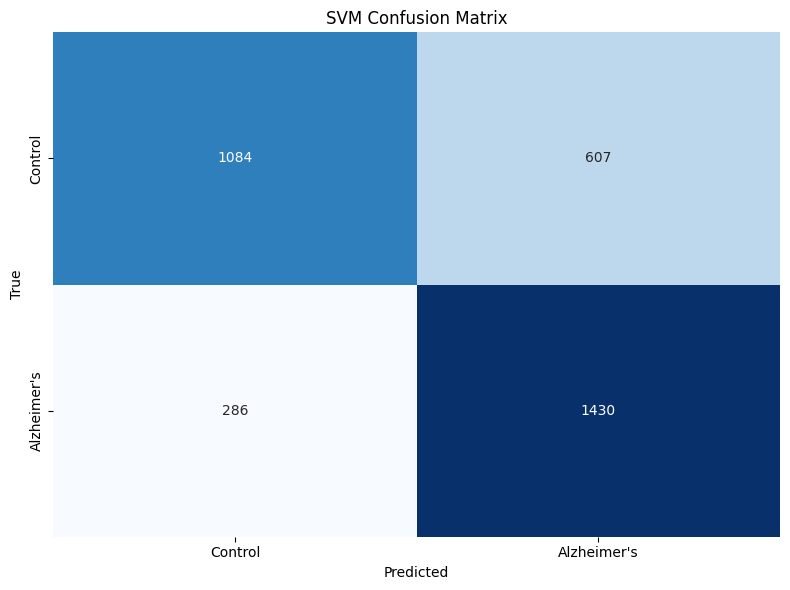

In [135]:
# 2. SVM
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_pca, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test_pca)

# Evaluate
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM accuracy: {acc_svm:.4f}")

# Print classification report
report_svm = classification_report(y_test, y_pred_svm, target_names=['Control', 'Alzheimer\'s'])
print(report_svm)

# Plot confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'Alzheimer\'s'],
            yticklabels=['Control', 'Alzheimer\'s'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

Gradient Boosting accuracy: 0.7311
              precision    recall  f1-score   support

     Control       0.75      0.68      0.71      1691
 Alzheimer's       0.71      0.78      0.75      1716

    accuracy                           0.73      3407
   macro avg       0.73      0.73      0.73      3407
weighted avg       0.73      0.73      0.73      3407



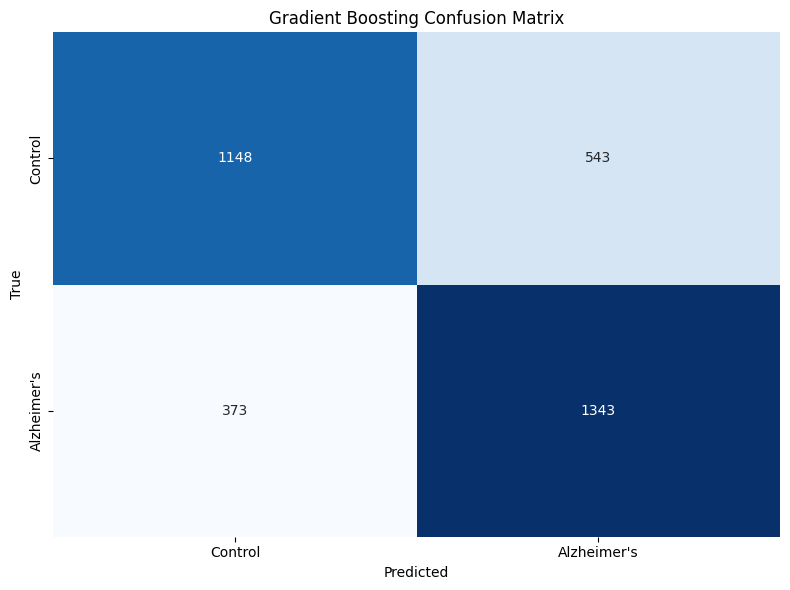

In [136]:
# 4. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_pca, y_train)

# Make predictions
y_pred_gb = gb.predict(X_test_pca)

# Evaluate
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting accuracy: {acc_gb:.4f}")

# Print classification report
report_gb = classification_report(y_test, y_pred_gb, target_names=['Control', 'Alzheimer\'s'])
print(report_gb)

# Plot confusion matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'Alzheimer\'s'],
            yticklabels=['Control', 'Alzheimer\'s'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Gradient Boosting Confusion Matrix')
plt.tight_layout()
plt.show()

Logistic Regression accuracy: 0.7156
              precision    recall  f1-score   support

     Control       0.78      0.60      0.68      1691
 Alzheimer's       0.68      0.83      0.75      1716

    accuracy                           0.72      3407
   macro avg       0.73      0.71      0.71      3407
weighted avg       0.73      0.72      0.71      3407



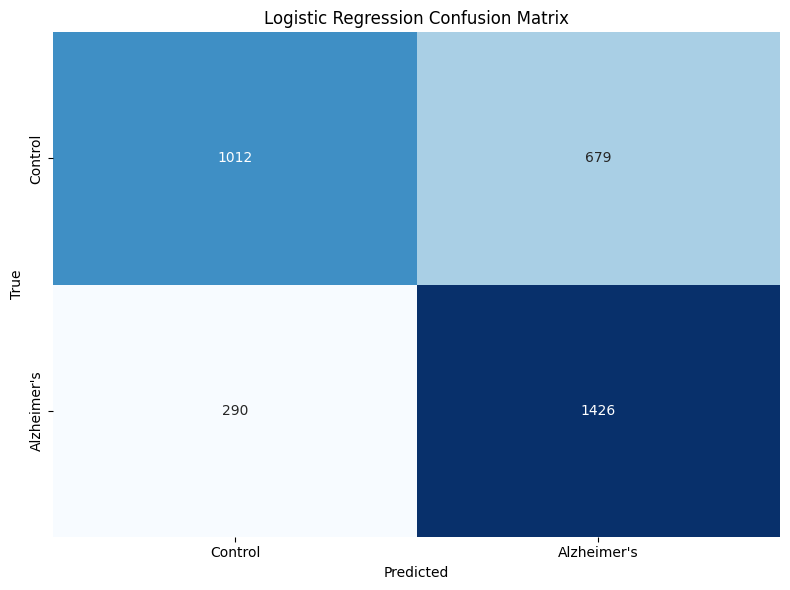

In [137]:
# 5. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test_pca)

# Evaluate
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression accuracy: {acc_lr:.4f}")

# Print classification report
report_lr = classification_report(y_test, y_pred_lr, target_names=['Control', 'Alzheimer\'s'])
print(report_lr)

# Plot confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'Alzheimer\'s'],
            yticklabels=['Control', 'Alzheimer\'s'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

Neural Network accuracy: 0.7532
              precision    recall  f1-score   support

     Control       0.77      0.72      0.74      1691
 Alzheimer's       0.74      0.79      0.76      1716

    accuracy                           0.75      3407
   macro avg       0.75      0.75      0.75      3407
weighted avg       0.75      0.75      0.75      3407



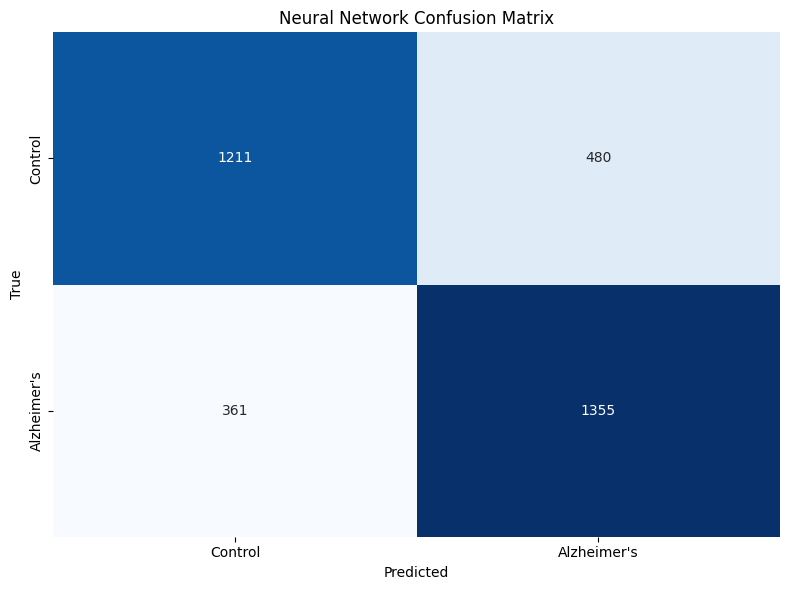

In [138]:
# 6. Neural Network (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp.fit(X_train_pca, y_train)

# Make predictions
y_pred_mlp = mlp.predict(X_test_pca)

# Evaluate
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Neural Network accuracy: {acc_mlp:.4f}")

# Print classification report
report_mlp = classification_report(y_test, y_pred_mlp, target_names=['Control', 'Alzheimer\'s'])
print(report_mlp)

# Plot confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'Alzheimer\'s'],
            yticklabels=['Control', 'Alzheimer\'s'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Neural Network Confusion Matrix')
plt.tight_layout()
plt.show()

In [139]:
# 7. Compare all models
model_names = ['KNN', 'SVM', 'Random Forest', 'Gradient Boosting', 'Logistic Regression', 'Neural Network']
accuracies = [acc_knn, acc_svm, acc_rf, acc_gb, acc_lr, acc_mlp]

# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
}).sort_values('Accuracy', ascending=False)

# Plot comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=model_comparison)
plt.title('Model Comparison - Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)  # Set y-axis to start from 0.5 for better visibility
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Model performance ranking:")
print(model_comparison)

# Identify best model
best_model = model_comparison.iloc[0]['Model']
best_accuracy = model_comparison.iloc[0]['Accuracy']
print(f"\nBest performing model: {best_model} with accuracy {best_accuracy:.4f}")

NameError: name 'acc_knn' is not defined

In [ ]:
# SVM with k-fold cross-validation
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize SVM model
svm = SVC(probability=True, random_state=42)

# Set up k-fold cross-validation
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Perform cross-validation to get scores
cv_scores = cross_val_score(svm, X_train_pca, y_train, cv=kf, scoring='accuracy')

# Print cross-validation results
print(f"SVM Cross-Validation Scores: {cv_scores}")
print(f"SVM Mean CV Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Get cross-validated predictions for the training set
y_train_pred_cv = cross_val_predict(svm, X_train_pca, y_train, cv=kf)

# Print classification report for cross-validated predictions
print("\nCross-Validated Classification Report (Training Set):")
cv_report = classification_report(y_train, y_train_pred_cv, target_names=['Control', 'Alzheimer\'s'])
print(cv_report)

# Plot cross-validation confusion matrix
cv_cm = confusion_matrix(y_train, y_train_pred_cv)
plt.figure(figsize=(8, 6))
sns.heatmap(cv_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'Alzheimer\'s'],
            yticklabels=['Control', 'Alzheimer\'s'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM Cross-Validation Confusion Matrix')
plt.tight_layout()
plt.show()

# Train the SVM on the entire training set
svm.fit(X_train_pca, y_train)

# Make predictions on the test set
y_test_pred = svm.predict(X_test_pca)
y_test_proba = svm.predict_proba(X_test_pca)[:, 1]

# Evaluate on test set
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\nSVM Test Accuracy: {test_acc:.4f}")

# Print classification report for test set
print("\nTest Set Classification Report:")
test_report = classification_report(y_test, y_test_pred, target_names=['Control', 'Alzheimer\'s'])
print(test_report)

# Plot test set confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'Alzheimer\'s'],
            yticklabels=['Control', 'Alzheimer\'s'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# SVM with GridSearchCV and k-fold validation
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3] # only relevant for poly kernel
}

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# Set up GridSearchCV with k-fold validation
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',
    return_train_score=True,
    verbose=1,
    n_jobs=-1
)

# Perform grid search
print("Starting grid search for SVM hyperparameters...")
grid_search.fit(X_train_pca, y_train)

# Print results
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Get best model
best_svm = grid_search.best_estimator_

# Make predictions with best model
y_test_pred_best = best_svm.predict(X_test_pca)
y_test_proba_best = best_svm.predict_proba(X_test_pca)[:, 1]

# Evaluate best model
best_acc = accuracy_score(y_test, y_test_pred_best)
print(f"\nOptimized SVM Test Accuracy: {best_acc:.4f}")

# Print classification report for best model
print("\nOptimized SVM Classification Report (Test Set):")
best_report = classification_report(y_test, y_test_pred_best, target_names=['Control', 'Alzheimer\'s'])
print(best_report)

# Plot confusion matrix for best model
best_cm = confusion_matrix(y_test, y_test_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'Alzheimer\'s'],
            yticklabels=['Control', 'Alzheimer\'s'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Optimized SVM Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot ROC curve for best model
fpr_best, tpr_best, _ = roc_curve(y_test, y_test_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(10, 8))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Optimized SVM ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Visualize hyperparameter tuning results
# Extract results from grid search
results = pd.DataFrame(grid_search.cv_results_)

# Plot C parameter vs accuracy for different kernels
plt.figure(figsize=(14, 8))

# Get unique kernels
kernels = results['param_kernel'].unique()

for kernel in kernels:
    # Filter for this kernel
    kernel_results = results[results['param_kernel'] == kernel]
    
    # Group by C and get mean test score
    c_scores = kernel_results.groupby('param_C')['mean_test_score'].mean()
    
    # Plot
    plt.plot(c_scores.index, c_scores.values, marker='o', label=f'kernel={kernel}')

plt.xscale('log')
plt.xlabel('C parameter (log scale)')
plt.ylabel('Mean CV Accuracy')
plt.title('SVM Hyperparameter Tuning: C parameter vs Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot learning curve for best model
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    best_svm, X_train_pca, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=kf, 
    scoring='accuracy'
)

# Calculate mean and std for train/validation scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 8))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, 
         label='Training accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, valid_mean, color='green', marker='s', markersize=5, 
         label='Validation accuracy')
plt.fill_between(train_sizes, valid_mean + valid_std, valid_mean - valid_std, alpha=0.15, color='green')

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('SVM Learning Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
'''
To learn: 
difference between explained and culmalative varaiance as well as the PCA graph 
'''